## EX: 1D Signal Classification

In this exercise, we will build a 1D-CNN to act as an automated Electronic Warfare (EW) officer. It will process raw time-series data to classify incoming radio frequencies as either friendly telemetry (smooth sine waves) or hostile tracking radar (sharp square pulses), even when both signals are heavily jammed with static noise.

* **Generate Signal Data:** Create 1,000 synthetic radio signals. 500 will be friendly smooth waves, and 500 will be hostile square pulses. We will inject heavy random noise to simulate EW jamming.

* **Reshape for Keras:** CNNs expect data in a specific format: `(batch_size, time_steps, features)`. We must shape our data to represent 100 time steps of a single audio channel.

* **Build Architecture:** Deploy a `Conv1D` layer to slide a filter across time, followed by `MaxPooling1D` to compress the signal, and a `Dense` layer to make the final binary classification.

* **Evaluate & Visualize:** Plot what the raw, jammed signals look like, and show the network's training performance.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

Training 1D-CNN on Jammed Signals...
Training Complete.

Test Accuracy on Unseen Signals: 99.50%


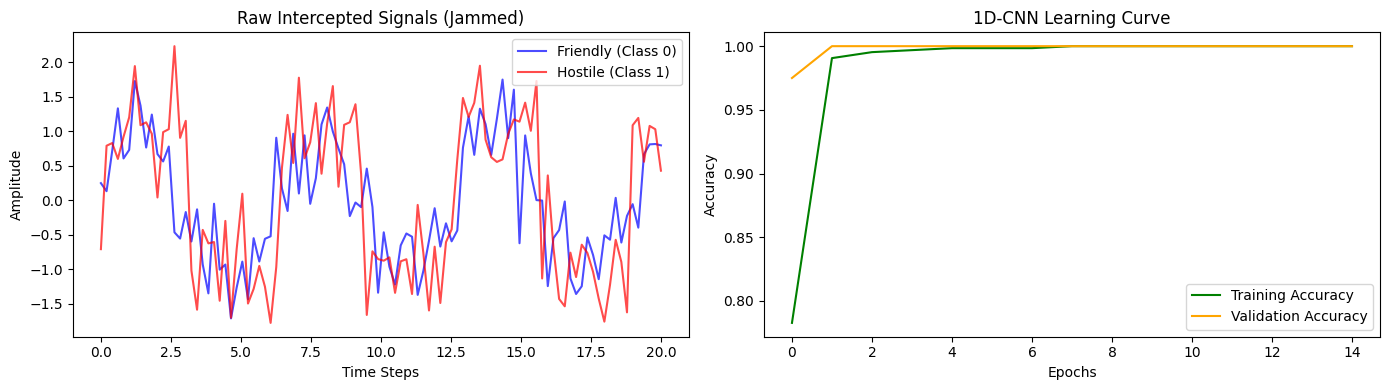

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# 1. Generate Jammed EW Signal Data
np.random.seed(42)
n_samples = 1000
time_steps = 100

# Create a time axis
t = np.linspace(0, 20, time_steps)

X = []
y = []

for i in range(n_samples):
    noise = np.random.normal(0, 0.5, time_steps) # Heavy EW static
    if i % 2 == 0:
        # Class 0: Friendly Telemetry (Smooth Sine Wave + Noise)
        signal = np.sin(t) + noise
        y.append(0)
    else:
        # Class 1: Hostile Radar Lock (Square Pulse + Noise)
        signal = np.sign(np.sin(t)) + noise
        y.append(1)
    X.append(signal)

X = np.array(X)
y = np.array(y)

# 2. Reshape Data for 1D CNN (samples, time_steps, features/channels)
# We have 1 sensor channel receiving the RF data
X = X.reshape((n_samples, time_steps, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build the 1D-CNN Architecture
model = Sequential([
    # Slides a size-5 filter across the 100 time steps
    Conv1D(filters=16, kernel_size=5, activation='relu', input_shape=(time_steps, 1)),
    # Compresses the sequence, keeping only the strongest signals
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(), # Flatten the remaining 1D sequence into a standard array
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Binary Output: Friendly(0) vs Hostile(1)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("Training 1D-CNN on Jammed Signals...")
history = model.fit(X_train, y_train, epochs=15, validation_split=0.2, verbose=0)
print("Training Complete.\n")

# 5. Evaluate and Visualize
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy on Unseen Signals: {accuracy * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot A: What the raw data looks like
axes[0].plot(t, X[0].flatten(), label='Friendly (Class 0)', color='blue', alpha=0.7)
axes[0].plot(t, X[1].flatten(), label='Hostile (Class 1)', color='red', alpha=0.7)
axes[0].set_title('Raw Intercepted Signals (Jammed)')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

# Plot B: Training Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='green')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('1D-CNN Learning Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### Interpreting the Results

Look at the first plot ("Raw Intercepted Signals"). Because of the heavy simulated static noise, the visual difference between the blue smooth wave and the red square pulse is highly distorted. A traditional statistical model would struggle immensely with this chaos.

However, look at the learning curve. Within just 5 epochs, the 1D-CNN easily cuts through the noise and achieves near 100% accuracy on unseen validation data.

It achieves this because the `Conv1D` filter slides left-to-right through time. It isn't looking at single data points; it is looking at short 5-step sequences. It learns that the hostile radar has rapid, sharp vertical jumps in amplitude over those 5 steps, while the friendly signal has a gradual curve. The network successfully engineered its own feature detectors to find the mathematical "shape" of the threat hidden beneath the fog of war.